## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

   If the target variable is categorical, the task is classification. If it is numeric, the task is regression.

2. What is a confusion table/matrix? What does it help us understand about a model's performance? 

   A confusion matrix cross-tabulates the true labels with the predicted ones. It helps visualize how many labels the model predicted correctly.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

   Accuracy is the proportion of cases that were predicted correctly. It does not account for classes that appear less often and are thus missed by the model, giving it a high overall accuracy but low per-class accuracy.

5. What does the root mean squared error quantify about a particular model?

   It measures the average magnitude of prediction error.

6. What are overfitting and underfitting?

   Overfitting is when the model is overly sensitive to the training data, and performs poorly on data that has never been seen before. Underfitting is when the model generalizes across data, performing poorly on training and new data.

7. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

   The training set is used to train the model, while the test set is used to evaluate its performance. This means the model can be evaluated on unseen data, improving estimates for model performance.

8. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

   When reporting the label as a prediction, it is simpler to understand but doesn't indicate how confident the model is. A probability distribution is more complex but includes confidence information, allowing for better usage in downstream prediction and analytical models.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.

   Iterated through odd $k$-values up to the sample size and took the model with the highest test accuracy.

4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

   Accuracy was 41%. The model tends to mispredict mine types 3, 4, and 5.

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

   Given it's low accuracy, I would advise someone to only use it for mine types 1 and 2, and then only as a guide rather than a source of truth.

In [2]:
df_mine = pd.read_csv("data/land_mines.csv")
df_mine.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


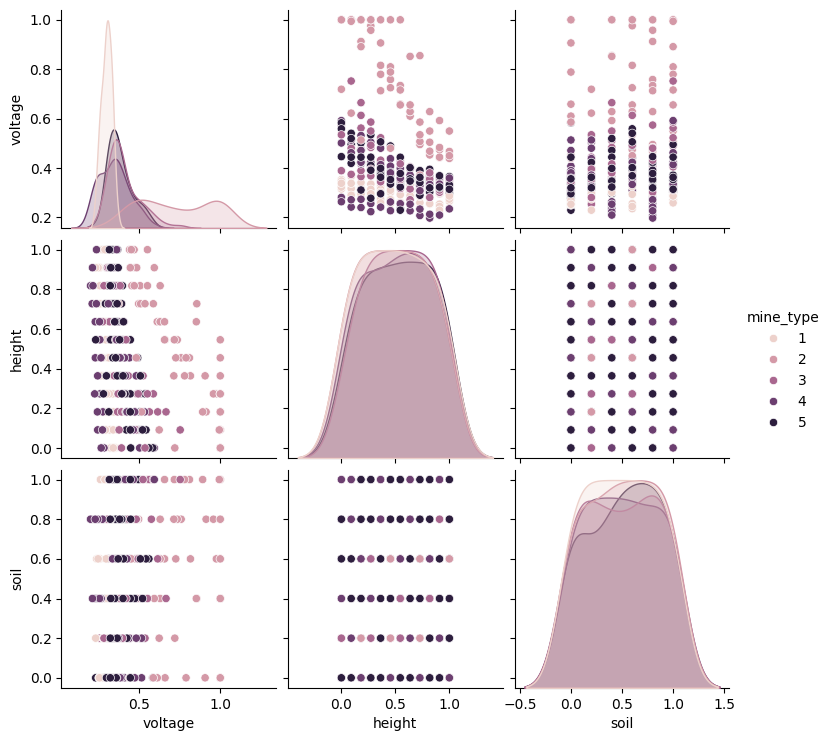

In [27]:
sns.pairplot(df_mine, hue="mine_type")
plt.show()

In [46]:
X = df_mine[["voltage", "height", "soil"]]
y = df_mine["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=100)

Test accuracy for 1 neighbors is 0.40236686390532544; train accuracy for 1 neighbors is 1.0
Test accuracy for 3 neighbors is 0.40828402366863903; train accuracy for 3 neighbors is 0.6449704142011834
Test accuracy for 5 neighbors is 0.3905325443786982; train accuracy for 5 neighbors is 0.5739644970414202
Test accuracy for 7 neighbors is 0.3668639053254438; train accuracy for 7 neighbors is 0.5798816568047337
Test accuracy for 9 neighbors is 0.378698224852071; train accuracy for 9 neighbors is 0.5266272189349113
Test accuracy for 11 neighbors is 0.40828402366863903; train accuracy for 11 neighbors is 0.5207100591715976
Test accuracy for 13 neighbors is 0.41420118343195267; train accuracy for 13 neighbors is 0.5325443786982249
Test accuracy for 15 neighbors is 0.378698224852071; train accuracy for 15 neighbors is 0.4911242603550296
Test accuracy for 17 neighbors is 0.3905325443786982; train accuracy for 17 neighbors is 0.4378698224852071
Test accuracy for 19 neighbors is 0.360946745562130

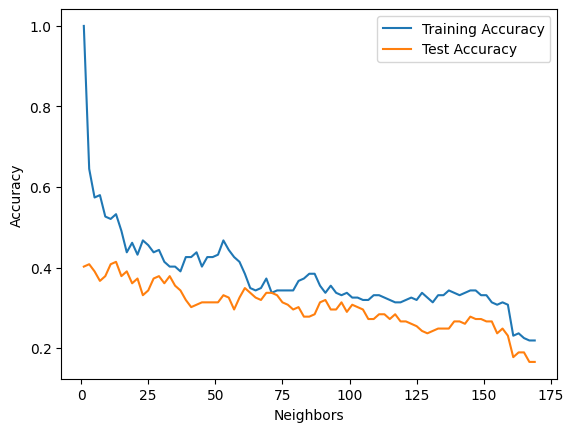

In [57]:
k_grid = np.array([(2*k+1) for k in range(0, 85)])
test_accuracy = []
train_accuracy = []

for k in k_grid:
    model = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    model = model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    test_acc = model.score(X_test, y_test)
    train_acc = model.score(X_train, y_train)

    print(f"Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}")
    test_accuracy.append(test_acc)
    train_accuracy.append(train_acc)
    
sns.lineplot(x=k_grid, y=train_accuracy, label="Training Accuracy").set(xlabel="Neighbors", ylabel="Accuracy")
sns.lineplot(x=k_grid, y=test_accuracy, label="Test Accuracy")
plt.show()

In [60]:
is_optimal = test_accuracy == np.max(test_accuracy)
optimal_indices = np.where(is_optimal)
k_optimal = k_grid[optimal_indices]

print(k_optimal)

[13]


In [61]:
model_best = Pipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=13))
])

model_best.fit(X_train, y_train)

y_hat = model_best.predict(X_test)
print(pd.crosstab(y_test, y_hat))
model_best.score(X_test, y_test)

col_0       1   2   3  4   5
mine_type                   
1          25   0  10  0   3
2           0  22   6  3   4
3           2   3  11  1  16
4          15   0   9  4   7
5           7   2  11  0   8


0.41420118343195267

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?

   The model predictions generally decrease as $k$ increases, from a max of ~42000 at $k = 3$ to ~27000 at $k = 300$.

5. Determine the optimal $k$ for these data.

   Optimal $k$ is 100, with the lowest MSE.

6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

   The model overfits for low $k$ and underfits for high $k$.

In [ ]:
df_cars = pd.read_csv("data/USA_cars_datasets.csv")
df_cars = df_cars[["price", "year", "mileage"]]
df_cars.head()

,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [116]:
X = df_cars[["year", "mileage"]]
y = df_cars["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

Test accuracy for 3 neighbors is 0.09819949899421776; train accuracy for 3 neighbors is 0.5112098315647668; MSE for 3 neighbors is 126118037.16488889


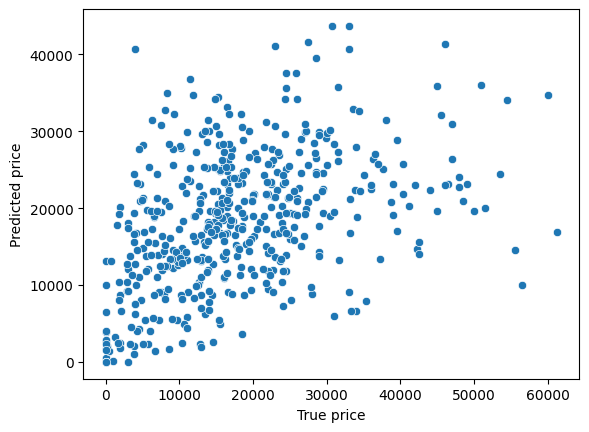

Test accuracy for 10 neighbors is 0.20878113132203258; train accuracy for 10 neighbors is 0.37026279389891015; MSE for 10 neighbors is 110653044.18681999


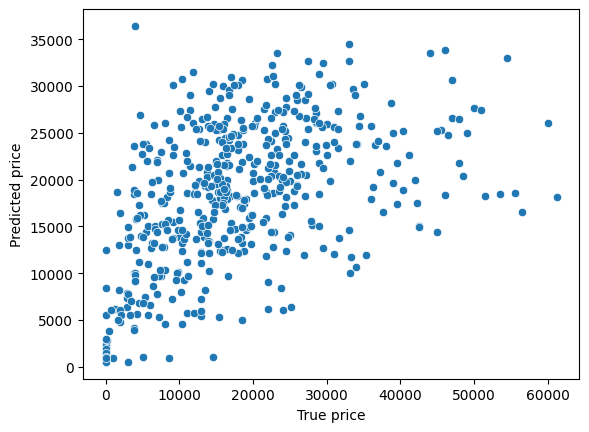

Test accuracy for 25 neighbors is 0.2622575823412392; train accuracy for 25 neighbors is 0.3288623994682979; MSE for 25 neighbors is 103174289.15223679


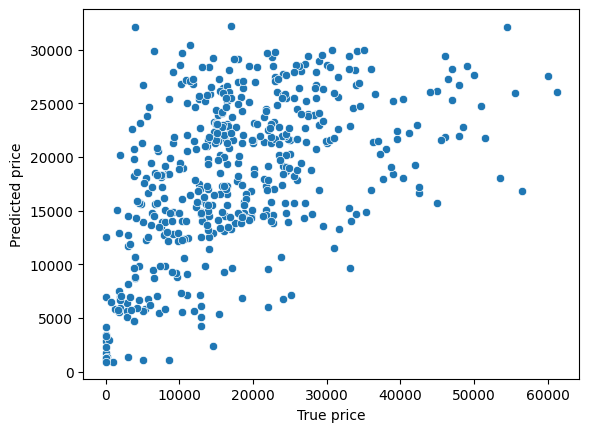

Test accuracy for 50 neighbors is 0.2872134565113068; train accuracy for 50 neighbors is 0.31290192100127245; MSE for 50 neighbors is 99684175.9148272


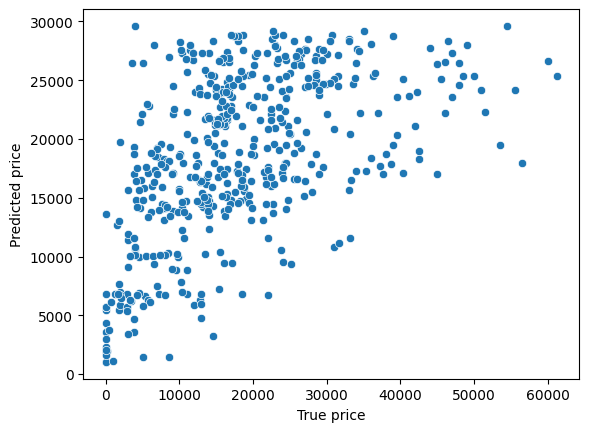

Test accuracy for 100 neighbors is 0.2972788629038581; train accuracy for 100 neighbors is 0.29481401170278854; MSE for 100 neighbors is 98276515.02300058


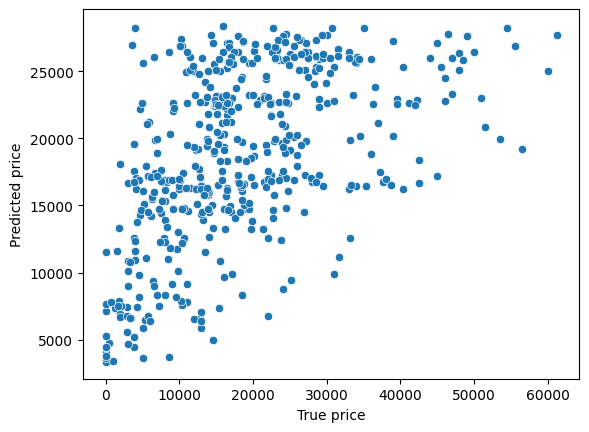

Test accuracy for 300 neighbors is 0.2815422715302932; train accuracy for 300 neighbors is 0.26602477420684745; MSE for 300 neighbors is 100477298.914212


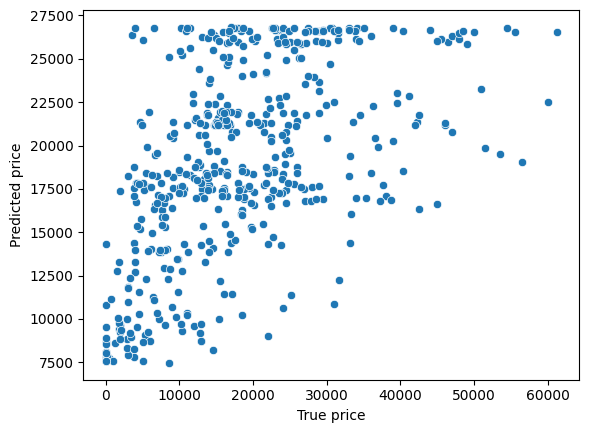

In [120]:
k_grid = np.array([3, 10, 25, 50, 100, 300])

for k in k_grid:
    model = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    
    model = model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    test_acc = model.score(X_test, y_test)
    train_acc = model.score(X_train, y_train)
    mse = mean_squared_error(y_test, y_hat)

    print(f"Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}; MSE for {k} neighbors is {mse}")
    sns.scatterplot(x=y_test, y=y_hat)
    plt.xlabel("True price")
    plt.ylabel("Predicted price")
    plt.show()

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?

   Age and serum creatinine.

3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?

   Sex.

4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.

   Optimal $k$ for $k$-NN classification is 5 with 73% accuracy.

8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

   The second model has lower accuracy. Too many variables can cause the model to overfit.

In [83]:
df_heart = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
df_heart.drop(columns=["time"], inplace=True)
df_heart.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


In [88]:
df_heart.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.004316


In [94]:
dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for column in dummy_vars:
    print(pd.crosstab(df_heart[column], df_heart["DEATH_EVENT"]))

DEATH_EVENT    0   1
anaemia             
0            120  50
1             83  46
DEATH_EVENT    0   1
diabetes            
0            118  56
1             85  40
DEATH_EVENT            0   1
high_blood_pressure         
0                    137  57
1                     66  39
DEATH_EVENT    0   1
sex                 
0             71  34
1            132  62
DEATH_EVENT    0   1
smoking             
0            137  66
1             66  30


In [133]:
X = df_heart[["age", "serum_creatinine", "sex"]]
y = df_heart["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [ ]:
k_grid = np.array([(2*k+1) for k in range(0, y_train.size // 2)])
test_accuracy = []
train_accuracy = []

for k in k_grid:
    model = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    model = model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    test_acc = model.score(X_test, y_test)
    train_acc = model.score(X_train, y_train)

    print(f"Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}")
    test_accuracy.append(test_acc)
    train_accuracy.append(train_acc)

is_optimal = test_accuracy == np.max(test_accuracy)
optimal_indices = np.where(is_optimal)
k_optimal = k_grid[optimal_indices]

print(f"\nOptimal k = {k_optimal}, accuracy = {np.max(test_accuracy)}")

Test accuracy for 1 neighbors is 0.65; train accuracy for 1 neighbors is 0.9497907949790795
Test accuracy for 3 neighbors is 0.7; train accuracy for 3 neighbors is 0.8200836820083682
Test accuracy for 5 neighbors is 0.7333333333333333; train accuracy for 5 neighbors is 0.7740585774058577
Test accuracy for 7 neighbors is 0.6833333333333333; train accuracy for 7 neighbors is 0.7489539748953975
Test accuracy for 9 neighbors is 0.6666666666666666; train accuracy for 9 neighbors is 0.7405857740585774
Test accuracy for 11 neighbors is 0.6833333333333333; train accuracy for 11 neighbors is 0.7531380753138075
Test accuracy for 13 neighbors is 0.6833333333333333; train accuracy for 13 neighbors is 0.7531380753138075
Test accuracy for 15 neighbors is 0.6833333333333333; train accuracy for 15 neighbors is 0.7489539748953975
Test accuracy for 17 neighbors is 0.6666666666666666; train accuracy for 17 neighbors is 0.7322175732217573
Test accuracy for 19 neighbors is 0.65; train accuracy for 19 neigh

In [139]:
X = df_heart.drop(columns=["DEATH_EVENT"])
y = df_heart["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [140]:
k_grid = np.array([(2*k+1) for k in range(0, y_train.size // 2)])
test_accuracy = []
train_accuracy = []

for k in k_grid:
    model = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    model = model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    test_acc = model.score(X_test, y_test)
    train_acc = model.score(X_train, y_train)

    print(f"Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}")
    test_accuracy.append(test_acc)
    train_accuracy.append(train_acc)

is_optimal = test_accuracy == np.max(test_accuracy)
optimal_indices = np.where(is_optimal)
k_optimal = k_grid[optimal_indices]

print(f"\nOptimal k = {k_optimal}, accuracy = {np.max(test_accuracy)}")

Test accuracy for 1 neighbors is 0.6; train accuracy for 1 neighbors is 1.0
Test accuracy for 3 neighbors is 0.6333333333333333; train accuracy for 3 neighbors is 0.8117154811715481
Test accuracy for 5 neighbors is 0.6666666666666666; train accuracy for 5 neighbors is 0.7489539748953975
Test accuracy for 7 neighbors is 0.6833333333333333; train accuracy for 7 neighbors is 0.7154811715481172
Test accuracy for 9 neighbors is 0.7; train accuracy for 9 neighbors is 0.6903765690376569
Test accuracy for 11 neighbors is 0.7; train accuracy for 11 neighbors is 0.698744769874477
Test accuracy for 13 neighbors is 0.6833333333333333; train accuracy for 13 neighbors is 0.698744769874477
Test accuracy for 15 neighbors is 0.6666666666666666; train accuracy for 15 neighbors is 0.6903765690376569
Test accuracy for 17 neighbors is 0.65; train accuracy for 17 neighbors is 0.702928870292887
Test accuracy for 19 neighbors is 0.6666666666666666; train accuracy for 19 neighbors is 0.698744769874477
Test acc

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)